In [48]:
# one of the package managers uv or pip or conda has f*cked up my PATH
import sys
sys.path.append("/home/macbuse/miniconda3/lib/python3.11/site-packages")
 
import matplotlib.pyplot as plt
import numpy as np 

import re
import requests
import json

import html #used for escaping entities

from collections import Counter #basic countings

---
# Dropdowns

U can get the department and the altitude from the dropdwn
at the top on the root **romma.fr**

In [49]:
user_agent = {'User-agent': 'Mozilla/5.0'}
r = requests.get('http://romma.fr', headers=user_agent)

In [50]:
pp = re.compile('<span>.+?(\d+\-.*?)</span>.*?<ul class="dropdown">\s+(.*?)</ul>', re.DOTALL)

text  = html.unescape(r.text) # swap out old style entities
mm = pp.findall(text)
dept, station_lists = list(zip(*mm))
dept_codes = [_[:2] for _ in dept]

In [51]:
dept_codes

['01',
 '04',
 '06',
 '07',
 '13',
 '26',
 '30',
 '38',
 '39',
 '69',
 '73',
 '74',
 '83',
 '84']

In [52]:
p_station =  re.compile('id=(\d+).*?([A-Z].*?), (\d+)')

def do_stations(x):

    ids, names, alts = list(zip(*p_station.findall(x)))
    ids = [int(_) for _ in ids]
    alts = [int(_) for _ in alts]
    return ids, names, alts

gps = [ do_stations(_) for _ in station_lists]

#num, idx, name = list(zip(*stuff[-7:]))

# Construct the dictionary from your arrays
stations_by_dept = dict(zip(dept_codes, gps))

# Write to the file preserving accents
with open('stations_by_dept.json', 'w', encoding='utf-8') as f:
    json.dump(stations_by_dept, f, ensure_ascii=False, indent=2)


In [53]:

# Convert directly to a DataFrame and specify column names
df = pd.DataFrame(zip(*stations_by_dept['38']), 
                  columns=['ID', 'Station', 'Altitude'])

# Sort by the first column ('ID')
df_sorted = df.sort_values(by='Altitude', ascending=True).reset_index(drop=True)

df_sorted[:20]

,ID,Station,Altitude
0,287,LE PEAGE-DE-ROUSSILLON,156
1,6,LE VERSOUD,220
2,4,ST-MARTIN-D'HÈRES,220
3,14,BOUVESSE-QUIRIEU,222
4,183,LUZINAY,222
5,289,FRONTONAS,247
6,284,FRONTONAS,255
7,50,L'ISLE-D'ABEAU,260
8,173,NOYAREY,260
9,94,TREPT,265


In [54]:
url = r'https://www.romma.fr/carte.php?dept=0'
#https://stackoverflow.com/questions/38489386/python-requests-403-forbidden
user_agent = {'User-Agent': "Mozilla/5.0 (X11; CrOS x86_64 13099.62.0) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/84.0.4147.83 Safari/537.36"}
#params = {'dept' : 0}
params = {}
  
r = requests.get(url, 
                headers=user_agent,
                params=params)

In [55]:
ids, names, _ = stations_by_dept['38']

In [56]:
pp = re.compile('id=(\d+)')
found = pp.findall(r.text)


---
## look for stations that have dropped

In [57]:
from collections import Counter
# Step 1: Count the occurrences of each element
counts = Counter(found)

# Step 2: Filter out elements whose count is NOT equal to 3
not_threes = [element for element, count in counts.items() if count != 3]

print(not_threes)


['19', '50', '56', '72', '76', '77', '84', '104', '110', '126', '806', '130', '708', '180', '185', '717', '727', '207', '210', '733', '218', '219', '239', '244', '746', '253', '262', '270', '768']


---
# Get a view of the data for all the depts

In [6]:
import pandas as pd

# Your original list comprehension
stuff = [(len(x[0]), dept[i]) for i, x in enumerate(gps)]

# Convert to DataFrame and label the columns
df = pd.DataFrame(stuff, columns=['Num_Stations',  'Department'])

# Sort by the busiest departments first to see your dense areas
df_sorted = df.sort_values(by='Num_Stations', ascending=False)

# Sort descending, grab the first 7, and extract their original index positions
top_7_indices = df_sorted.head(7).index

# If you need it as a standard Python list:
idxs = top_7_indices.tolist()

df_sorted

,Num_Stations,Department
7,66,38-ISÈRE
10,44,73-SAVOIE
11,40,74-HAUTE-SAVOIE
5,34,26-DRÔME
0,33,01-AIN
1,23,04-ALPES DE HTE-PROVENCE
2,15,06-ALPES-MARITIMES
13,14,84-VAUCLUSE
9,7,69-RHÔNE
6,4,30-GARD


In [294]:
# this was for gemini but now there is the json
with open('gps.txt','w') as fp:
    fp.write(str(gps))

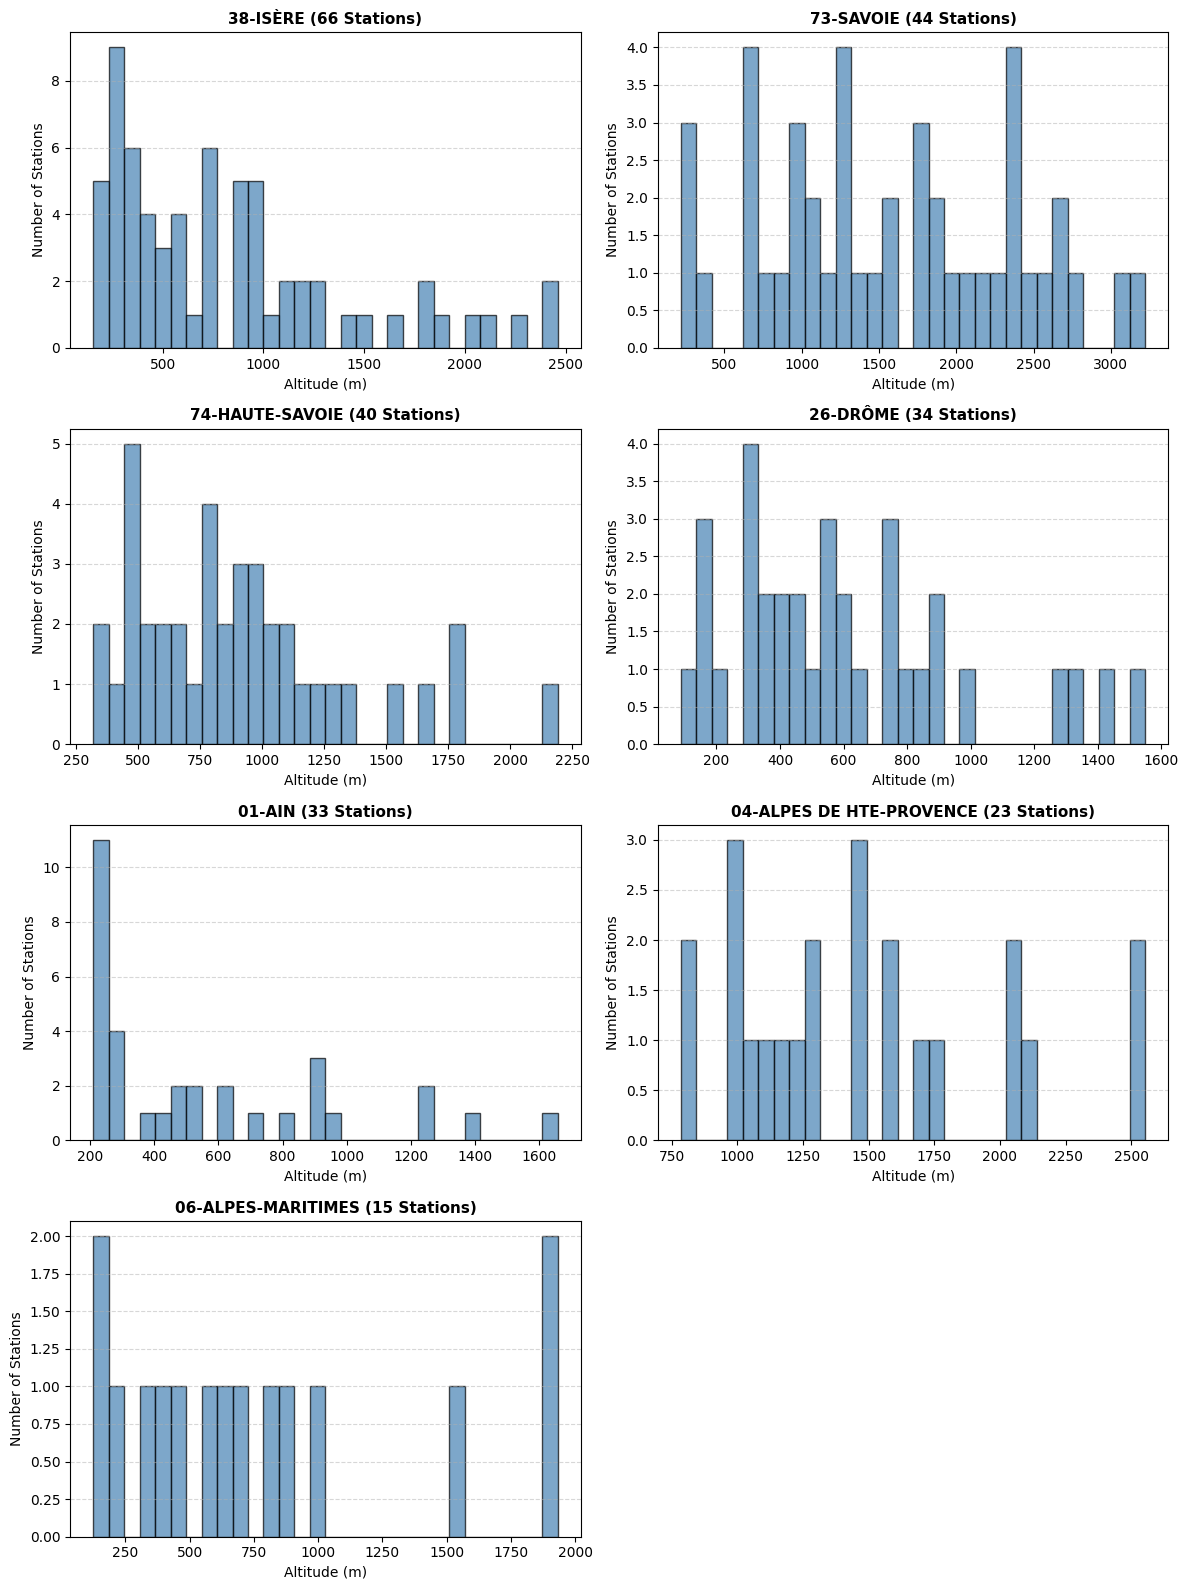

In [58]:
import math

# 1. Define the range of k indices you want to plot
# Update this list or use range(len(gps)) depending on your data structure
k_indices = idxs
num_plots = len(k_indices)

# 2. Determine grid dimensions dynamically (aiming for 2 columns max)
num_cols = 2 if num_plots > 1 else 1
num_rows = math.ceil(num_plots / num_cols)

# 3. Initialize the multiplot figure
fig, axes = plt.subplots(num_rows, num_cols, figsize=(12, 4 * num_rows))

# Flatten axes array to make looping easy, even if it's a 1D grid or single plot
if num_plots > 1:
    axes = axes.flatten()
else:
    axes = [axes]

# 4. Loop over indices and build each subplot
for idx, k in enumerate(k_indices):
    ax = axes[idx]
    
    # Extract data for the current region
    altitudes = gps[k][2]
    num_stations = len(altitudes)
    
    # Plot individual histogram
    ax.hist(altitudes, bins=30, 
            edgecolor='black', alpha=0.7, color='steelblue')
    
    # Polish individual labels and dynamic title
    ax.set_xlabel('Altitude (m)', fontsize=10)
    ax.set_ylabel('Number of Stations', fontsize=10)
    ax.set_title(f'{dept[k]} ({num_stations} Stations)', fontsize=11, fontweight='bold')
    ax.grid(axis='y', linestyle='--', alpha=0.5)

# 5. Hide any unused subplot tiles in the grid
for j in range(idx + 1, len(axes)):
    fig.delaxes(axes[j])

# Adjust spacing and render
plt.tight_layout()
plt.show()


---
## check 

In [8]:
[ (x,y[1][0]) for x,y in zip(dept,gps)]

[('01-AIN', 'ST-VULBAS'),
 ('04-ALPES DE HTE-PROVENCE', 'GAP'),
 ('06-ALPES-MARITIMES', 'SOPHIA-ANTIPOLIS'),
 ('07-ARDÈCHE', 'TOURNON-SUR-RHÔNE'),
 ('13-BOUCHES-DU-RHONE', 'GRAVESON'),
 ('26-DRÔME', 'MONTELIMAR'),
 ('30-GARD', 'ST-PAUL-LES-FONTS'),
 ('38-ISÈRE', 'LE PEAGE-DE-ROUSSILLON'),
 ('39-JURA', 'MONTAGNA-LE-TEMPLIER'),
 ('69-RHÔNE', 'LYON'),
 ('73-SAVOIE', 'ST-GENIS-SUR-GUIERS'),
 ('74-HAUTE-SAVOIE', 'VALLIERES'),
 ('83-VAR', 'CHATEAUVIEUX'),
 ('84-VAUCLUSE', 'ORANGE')]

In [65]:
ids, names, alts = stations_by_dept['38'][:5]

[287,
 6,
 4,
 14,
 183,
 289,
 284,
 50,
 173,
 94,
 225,
 5,
 216,
 109,
 246,
 299,
 211,
 240,
 48,
 233,
 46,
 82,
 156,
 145,
 202,
 230,
 32,
 44,
 169,
 219,
 250,
 179,
 208,
 731,
 271,
 101,
 22,
 106,
 141,
 139,
 41,
 744,
 157,
 58,
 186,
 266,
 80,
 33,
 276,
 122,
 113,
 239,
 181,
 131,
 726,
 133,
 2102,
 100,
 502,
 3,
 2103,
 802,
 147,
 72,
 803,
 804]

---

In [10]:
with open('romma_2026_05_25_09-04.html','r') as fp:
    text = fp.read()

In [3]:
text[:100]

'<!DOCTYPE html PUBLIC "-//W3C//DTD XHTML 1.0 Strict//EN" "http://www.w3.org/TR/xhtml1/DTD/xhtml1-str'

In [11]:
p_row = re.compile(r'<tr>(.*?)</tr>', re.DOTALL)
p_tables = re.compile(r'<table class=.*?>(.*?)</table>(.*?)"', re.DOTALL)
data = p_tables.findall(text)
len(data)

631

In [12]:
data[0]

("<tr><td class=\\'none\\' width=\\'34%\\'>&nbsp;</td><td class=\\'blue\\' width=\\'22%\\'><strong>Actuel</strong></td><td class=\\'blue\\' width=\\'22%\\' >Max depuis 0h</td><td class=\\'blue\\' width=\\'22%\\' >Min depuis 0h</td></tr><tr><td class=\\'blue\\'>Temp&eacute;rature (°C)</td><td class=\\'blanc\\'><strong>18.4</strong></td><td class=\\'blanc\\'>18.8 &agrave; 08:23</td><td class=\\'blanc\\'>11.3 &agrave; 04:12</td></tr><tr><td class=\\'blue\\'>Humidit&eacute; (%)</td><td class=\\'blanc\\'><strong>51</strong></td><td class=\\'blanc\\'>64 &agrave; 02:06</td><td class=\\'blanc\\'>45 &agrave; 08:35</td></tr><tr><td class=\\'blue\\'>Vent et Dir (km/h)</td><td class=\\'blanc\\'><strong>5 </strong></td><td class=\\'blanc\\'>15 &agrave; 06:59</td><td class=\\'none\\'>&nbsp;</td></tr><tr><td class=\\'blue\\'>Rayonnement(w/m2)</td><td class=\\'blanc\\'><strong>522</strong></td><td class=\\'blanc\\'>522 &agrave; 08:52</td><td class=\\'none\\'>&nbsp;</td></tr><tr><td class=\\'blue\\'>Hu

In [59]:

tables, names = list(zip(*data))
all_names = ' '.join(names[::2])

p_name = re.compile(r".*?CAPTION,\s+\'(?P<station>.*?)\s\((?P<altitude>\d+)")
nn = p_name.findall(all_names)
nn[:10]

NameError: name 'data' is not defined

In [15]:
import html
import re

p_cell = re.compile('<td class=(.*?)</td>')

def get_station_type(x):
    try:
        rows = p_row.findall(x)
        station_data = [p_cell.findall(_) for _ in rows]

        # 1. Extract the raw matched strings
        raw_results = [ _[0] for _ in station_data[1:] if "blue" in _[0] ]

        # 2. Clean up any HTML entities converting them to proper UTF-8 strings
        clean_results = [html.unescape(item[len("\\'blue\\'>") :]) for item in raw_results]

        return clean_results
        
    except Exception:
        # Corrected capitalization for Python's None type
        return None

In [16]:
station_types = [get_station_type(_) for _ in tables[::2] ]

In [18]:
from collections import Counter

profile_distribution = Counter(
    len(_) for _ in station_types
)

In [19]:
profile_distribution

Counter({5: 98, 6: 75, 7: 54, 3: 45, 4: 35, 2: 7, 1: 2})

In [20]:
station_types[:3]

[['Température (°C)',
  'Humidité (%)',
  'Vent et Dir (km/h)',
  'Rayonnement(w/m2)',
  'Humidex',
  'Précip. (mm/h et mm)'],
 ['Température (°C)',
  'Humidité (%)',
  'Vent et Dir (km/h)',
  'Humidex',
  'Précip. (mm/h et mm)'],
 ['Température (°C)',
  'Humidité (%)',
  'Pression (hPa)',
  'Rayonnement(w/m2)',
  'Humidex',
  'Précip. (mm/h et mm)']]

In [21]:
unique_headers = list(set().union(*station_types))
unique_headers

['Température (°C)',
 'Vent et Dir (km/h)',
 'Windchill',
 'Rayonnement(w/m2)',
 'Précip. (mm/h et mm)',
 'Humidité (%)',
 'Pression (hPa)',
 'Humidex']

In [ ]:
def dump_stations():       
    base_url = 'https://www.romma.fr'
    url = base_url + '/frame_station24.php?id_station={}&tempe=1&humi=&pluie=&vent=&pressure=&rayonnement=&neige='

    headers = {'User-Agent': "Mozilla/5.0 (X11; CrOS x86_64 13099.62.0) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/84.0.4147.83 Safari/537.36",
             'Host': 'romma.fr',
            'Referer': f'https://www.romma.fr/station_24.php?id={ref_num}&tempe=1'}
    #30/5/2026 I changed Referer
    
    print(f'Fetching station {ref_num}')
    
    r = requests.post(url.format(ref_num) , 
                     headers=headers)
    
    return r.text